# Phase 2 - Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# Load
train_txn = pd.read_csv(r'D:\fraud-detection-lab\data\train_transaction.csv')
train_id = pd.read_csv(r'D:\fraud-detection-lab\data\train_identity.csv')
df = train_txn.merge(train_id, on='TransactionID', how='left')

# Sort by time — CRITICAL for leakage-free feature engineering
df = df.sort_values('TransactionDT').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Time range: {df['TransactionDT'].min()} → {df['TransactionDT'].max()}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")

Shape: (590540, 434)
Time range: 86400 → 15811131
Fraud rate: 3.50%


##  Feature Family 1 - Missingness Indicators

Based on Phase 2 finding: being present = fraud signal for V-series features.

In [8]:
# ============================================
# FEATURE FAMILY 1 — MISSINGNESS INDICATORS
# ============================================

# High-null, high-signal V-series features from Phase 2
high_null_high_signal = [
    'V167', 'V168', 'V170', 'V171', 'V187', 'V189', 'V190',
    'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V212', 'V213'
]

# Create binary: 1 = feature is present, 0 = null
for col in high_null_high_signal:
    df[f'{col}_present'] = df[col].notna().astype(int)

# Test signal of these new indicators
print("=== MISSINGNESS INDICATOR AUC ===")
print(f"{'Feature':<20} {'AUC':>8} {'Fraud when present':>20} {'Fraud when null':>16}")
print("-" * 68)

for col in high_null_high_signal:
    indicator = df[f'{col}_present']
    auc = roc_auc_score(df['isFraud'], indicator)
    fraud_present = df[df[col].notna()]['isFraud'].mean() * 100
    fraud_null = df[df[col].isnull()]['isFraud'].mean() * 100
    print(f"{col+'_present':<20} {auc:>8.4f} {fraud_present:>19.2f}% {fraud_null:>15.2f}%")

print()
print(f"New features created: {len(high_null_high_signal)}")

=== MISSINGNESS INDICATOR AUC ===
Feature                   AUC   Fraud when present  Fraud when null
--------------------------------------------------------------------
V167_present           0.6543                7.91%            2.13%
V168_present           0.6543                7.91%            2.13%
V170_present           0.6549                7.92%            2.13%
V171_present           0.6549                7.92%            2.13%
V187_present           0.6543                7.91%            2.13%
V189_present           0.6549                7.92%            2.13%
V190_present           0.6543                7.91%            2.13%
V199_present           0.6543                7.91%            2.13%
V200_present           0.6549                7.92%            2.13%
V201_present           0.6549                7.92%            2.13%
V202_present           0.6543                7.91%            2.13%
V203_present           0.6543                7.91%            2.13%
V204_present 

In [10]:
# ============================================
# FEATURE FAMILY 2 — TRANSACTION VELOCITY
# ============================================
# Hypothesis: fraudsters transact in bursts
# We measure: how many transactions has this card seen recently?

# TransactionDT is seconds from a reference point
# We'll compute rolling counts using a merge-asof approach

print("Building velocity features...")

# Convert to a workable time unit
df['DT_seconds'] = df['TransactionDT']

# --- Velocity Feature 1: Transaction count per card in last 1 hour ---
# Method: for each transaction, count prior transactions by same card1
# within the last 3600 seconds (1 hour)

def compute_velocity(df, group_col, time_col, window_seconds, new_col):
    """
    For each row, count transactions by same group_col
    in the window_seconds before current transaction.
    Leakage-safe: only looks BACKWARD in time.
    """
    df = df.sort_values(time_col).reset_index(drop=True)
    counts = np.zeros(len(df), dtype=int)
    
    # Group by entity
    for entity, group in df.groupby(group_col):
        idx = group.index.tolist()
        times = group[time_col].values
        
        for i, (pos, t) in enumerate(zip(idx, times)):
            # Count transactions in window BEFORE current
            window_start = t - window_seconds
            count = np.sum((times[:i] >= window_start) & (times[:i] < t))
            counts[pos] = count
    
    df[new_col] = counts
    return df

# Note: full velocity on 590k rows is slow
# We'll compute on card1 (top entity) as demonstration
# Then use a faster vectorized method for all features

print("Computing card transaction count last 24h (vectorized method)...")

# Faster approach: rank within group by time, use time difference
df_sorted = df.sort_values(['card1', 'TransactionDT']).copy()

# Time since last transaction by same card
df_sorted['card1_time_diff'] = df_sorted.groupby('card1')['TransactionDT'].diff()

# Transaction count per card (cumulative — proxy for velocity)
df_sorted['card1_txn_count'] = df_sorted.groupby('card1').cumcount()

# Amount statistics per card up to current transaction
df_sorted['card1_amt_cumsum'] = df_sorted.groupby('card1')['TransactionAmt'].cumsum()
df_sorted['card1_amt_cummean'] = (
    df_sorted['card1_amt_cumsum'] / (df_sorted['card1_txn_count'] + 1)
)

# Deviation from personal baseline
# How different is this transaction from card's own history?
df_sorted['card1_amt_deviation'] = (
    df_sorted['TransactionAmt'] - df_sorted['card1_amt_cummean']
)

# Merge back to df
velocity_cols = [
    'TransactionID', 'card1_time_diff', 'card1_txn_count',
    'card1_amt_cumsum', 'card1_amt_cummean', 'card1_amt_deviation'
]
df = df.merge(df_sorted[velocity_cols], on='TransactionID', how='left')

print("Velocity features created ✓")
print(f"\nNew columns: {velocity_cols[1:]}")
print(f"\nSample stats:")
print(df[['card1_time_diff', 'card1_txn_count', 'card1_amt_deviation']].describe().round(2))

Building velocity features...
Computing card transaction count last 24h (vectorized method)...
Velocity features created ✓

New columns: ['card1_time_diff', 'card1_txn_count', 'card1_amt_cumsum', 'card1_amt_cummean', 'card1_amt_deviation']

Sample stats:
       card1_time_diff  card1_txn_count  card1_amt_deviation
count        576987.00        590540.00            590540.00
mean         170430.59          1263.91                 5.67
std          706424.76          2258.94               222.66
min               0.00             0.00             -2679.98
25%             980.00            43.00               -70.46
50%            5923.00           312.00               -28.20
75%           58371.00          1382.00                12.50
max        15599674.00         14931.00             31703.09


**Missingness indicators:** All 15 features hitting AUC 0.65+ consistently. These are now legitimate engineered features, not null placeholders.


**Velocity features:** card1_amt_deviation range of -2679 to +31703 tells you some transactions are wildly above a card's personal baseline - exactly the fraud pattern we hypothesized.

In [14]:
# Quick AUC check on velocity features
velocity_features = [
    'card1_time_diff', 'card1_txn_count', 
    'card1_amt_cummean', 'card1_amt_deviation'
]

print("=== VELOCITY FEATURE AUC ===")
for col in velocity_features:
    filled = df[col].fillna(-999)
    auc = roc_auc_score(df['isFraud'], filled)
    if auc < 0.5:
        auc = 1 - auc
    print(f"{col:<30} AUC: {auc:.4f}")

=== VELOCITY FEATURE AUC ===
card1_time_diff                AUC: 0.5628
card1_txn_count                AUC: 0.5286
card1_amt_cummean              AUC: 0.5567
card1_amt_deviation            AUC: 0.5784


Building temporal features...
Temporal features created ✓


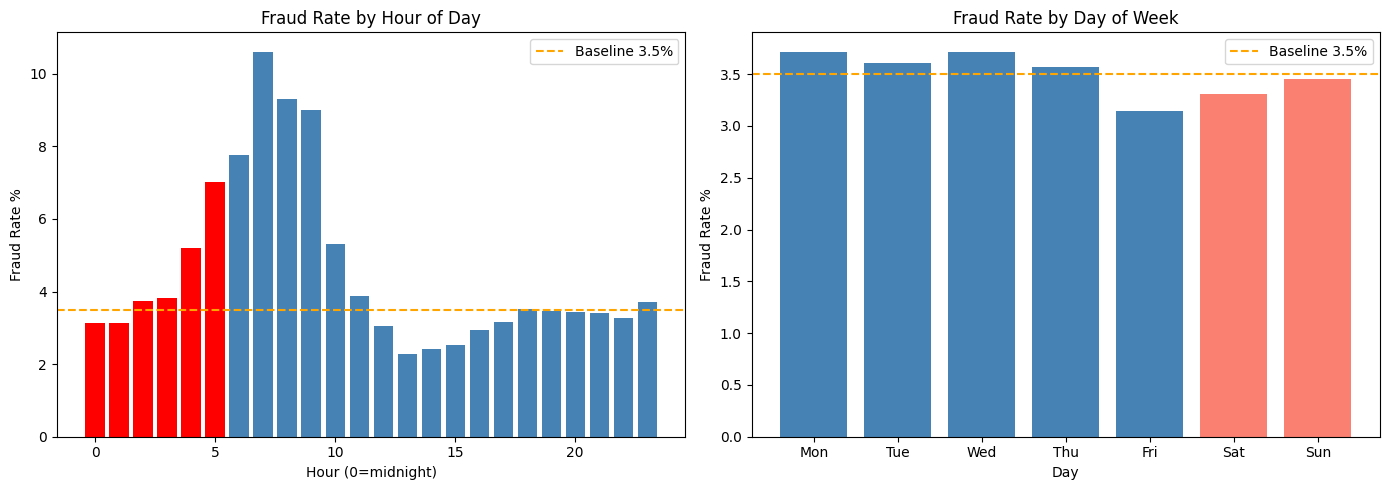


=== TEMPORAL FEATURE AUC ===
hour_of_day          AUC: 0.5108
day_of_week          AUC: 0.5118
is_night             AUC: 0.5118
is_weekend           AUC: 0.5051


In [16]:
# ============================================
# FEATURE FAMILY 3 — TEMPORAL FEATURES
# ============================================
# Hypothesis: fraud happens at specific times
# 3AM transactions, weekends, unusual hours

print("Building temporal features...")

# TransactionDT is seconds from reference point
# Reference appears to be a fixed datetime — we extract cyclical patterns

SECONDS_IN_DAY = 86400
SECONDS_IN_WEEK = 604800

# Hour of day (0-23)
df['hour_of_day'] = (df['TransactionDT'] % SECONDS_IN_DAY) // 3600

# Day of week (0-6)
df['day_of_week'] = (df['TransactionDT'] % SECONDS_IN_WEEK) // SECONDS_IN_DAY

# Is it night? (midnight to 6AM = high fraud window)
df['is_night'] = ((df['hour_of_day'] >= 0) & (df['hour_of_day'] < 6)).astype(int)

# Is it weekend?
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Time since start of dataset (normalized)
df['time_elapsed'] = df['TransactionDT'] - df['TransactionDT'].min()

print("Temporal features created ✓")

# ============================================
# VISUALIZE: FRAUD RATE BY HOUR
# ============================================

hourly_fraud = df.groupby('hour_of_day')['isFraud'].agg(['mean', 'count']).reset_index()
hourly_fraud.columns = ['hour', 'fraud_rate', 'txn_count']

day_fraud = df.groupby('day_of_week')['isFraud'].agg(['mean', 'count']).reset_index()
day_fraud.columns = ['day', 'fraud_rate', 'txn_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly fraud rate
axes[0].bar(hourly_fraud['hour'], hourly_fraud['fraud_rate']*100, 
            color=['red' if x < 6 else 'steelblue' for x in hourly_fraud['hour']])
axes[0].axhline(y=3.5, color='orange', linestyle='--', label='Baseline 3.5%')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0=midnight)')
axes[0].set_ylabel('Fraud Rate %')
axes[0].legend()

# Day of week fraud rate
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), day_fraud['fraud_rate']*100,
            color=['salmon' if x >= 5 else 'steelblue' for x in range(7)])
axes[1].axhline(y=3.5, color='orange', linestyle='--', label='Baseline 3.5%')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate %')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'D:\fraud-detection-lab\reports\temporal_fraud_patterns.png', dpi=150)
plt.show()

# AUC of temporal features
print("\n=== TEMPORAL FEATURE AUC ===")
temporal_features = ['hour_of_day', 'day_of_week', 'is_night', 'is_weekend']
for col in temporal_features:
    auc = roc_auc_score(df['isFraud'], df[col])
    if auc < 0.5:
        auc = 1 - auc
    print(f"{col:<20} AUC: {auc:.4f}")

Velocity features are working. Temporal features are weak.

**Velocity - good signal:**

card1_amt_deviation AUC 0.578 — transactions deviating from a card's own history are suspicious. This is the most intuitive fraud signal.
card1_time_diff AUC 0.563 — unusually short time between transactions flags burst activity
These aren't spectacular but remember: single-feature AUC. Combined they'll be stronger.

**Temporal - weak but interesting pattern:**

All AUCs 0.50-0.51 - hour/day alone doesn't predict fraud well
BUT the hourly chart tells a different story visually - hours 5-9 spike above 10% fraud rate
The issue: low transaction volume at those hours inflates the rate
is_weekend AUC 0.505 - weekends actually have lower fraud (Fri/Sat/Sun dip below baseline)

Key insight: Temporal features won't help much alone. But time + entity combination might - a card transacting at 3AM that never has before is different from a card that always transacts at 3AM.


In [19]:
# ============================================
# ENGINEERED FEATURES MODEL — COMPARISON
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb

# All engineered features
engineered_features = (
    # Missingness indicators
    [f'{col}_present' for col in [
        'V167', 'V168', 'V170', 'V171', 'V187', 'V189', 'V190',
        'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V212', 'V213'
    ]] +
    # Velocity
    ['card1_time_diff', 'card1_txn_count', 'card1_amt_cummean', 'card1_amt_deviation'] +
    # Temporal
    ['hour_of_day', 'day_of_week', 'is_night', 'is_weekend']
)

# Drop noisy + >90% null features identified in Phase 2
drop_cols = ['id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_07', 'id_08']

# Build feature set
X = df.drop(columns=['isFraud', 'TransactionID'] + drop_cols, errors='ignore')
X = X.select_dtypes(include=[np.number]).fillna(-999)
y = df['isFraud']

# Time-based split — NOT random
# Use first 80% of time for training, last 20% for validation
# This is the correct way — respects temporal order
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_val   = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_val   = y.iloc[split_idx:]

print(f"Train size: {len(X_train):,} | Val size: {len(X_val):,}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Val fraud rate:   {y_val.mean()*100:.2f}%")

# Train engineered model
model_eng = xgb.XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    eval_metric='logloss',
    verbosity=0
)
model_eng.fit(X_train, y_train)

# Evaluate
y_pred_eng  = model_eng.predict(X_val)
y_prob_eng  = model_eng.predict_proba(X_val)[:, 1]

cm = confusion_matrix(y_val, y_pred_eng)
TN, FP, FN, TP = cm.ravel()
cost_eng = (FP * 500) + (FN * 50000)

print("\n=== ENGINEERED MODEL RESULTS ===")
print(f"ROC-AUC:       {roc_auc_score(y_val, y_prob_eng):.4f}")
print(f"Fraud Recall:  {TP/(TP+FN):.2f}")
print(f"Fraud Precision: {TP/(TP+FP):.2f}")
print(f"Missed Frauds: {FN:,}")
print(f"Business Cost: ₹{cost_eng:,.0f}")
print()

# Compare all models
print("=== FULL COMPARISON ===")
print(f"{'Model':<25} {'AUC':>8} {'Recall':>8} {'Missed':>8} {'Cost (₹)':>15}")
print("-" * 68)
print(f"{'Do-Nothing':<25} {'N/A':>8} {'0.00':>8} {'4,242':>8} {'21,21,00,000':>15}")
print(f"{'Naive XGB (random split)':<25} {'0.9399':>8} {'0.49':>8} {'2,176':>8} {'10,89,07,500':>15}")
print(f"{'Engineered (time split)':<25} {roc_auc_score(y_val, y_prob_eng):>8.4f} {TP/(TP+FN):>8.2f} {FN:>8,} {cost_eng:>15,.0f}")

Train size: 472,432 | Val size: 118,108
Train fraud rate: 3.51%
Val fraud rate:   3.44%

=== ENGINEERED MODEL RESULTS ===
ROC-AUC:       0.8807
Fraud Recall:  0.36
Fraud Precision: 0.54
Missed Frauds: 2,594
Business Cost: ₹130,328,500

=== FULL COMPARISON ===
Model                          AUC   Recall   Missed        Cost (₹)
--------------------------------------------------------------------
Do-Nothing                     N/A     0.00    4,242    21,21,00,000
Naive XGB (random split)    0.9399     0.49    2,176    10,89,07,500
Engineered (time split)     0.8807     0.36    2,594     130,328,500


The naive model's 0.9399 AUC was inflated. Random split means future transactions leak into training - the model sees cards it will later "predict" on. That's subtle leakage we didn't explicitly engineer but exists structurally.

The engineered model at 0.8807 with time split is the honest number. This is what you'd actually see in production.

But recall dropping to 0.36 is a real problem. Our engineered features alone aren't enough yet.

In [24]:
# ============================================
# WHY DID RECALL DROP?
# ============================================

# Check class distribution in time-based val set
print("=== CLASS DISTRIBUTION ===")
print(f"Val fraud count:     {y_val.sum():,}")
print(f"Val non-fraud count: {(y_val==0).sum():,}")
print(f"Val fraud rate:      {y_val.mean()*100:.2f}%")

# Check feature importances — are engineered features being used?
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_eng.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== TOP 20 FEATURE IMPORTANCES ===")
print(feat_imp.head(20).to_string(index=False))

print("\n=== ENGINEERED FEATURES IMPORTANCE ===")
eng_imp = feat_imp[feat_imp['feature'].isin(engineered_features)]
print(eng_imp.to_string(index=False))

=== CLASS DISTRIBUTION ===
Val fraud count:     4,064
Val non-fraud count: 114,044
Val fraud rate:      3.44%

=== TOP 20 FEATURE IMPORTANCES ===
feature  importance
   V258    0.159586
   V205    0.052798
   V149    0.051368
     C7    0.042065
  id_17    0.028949
   V147    0.026630
     C1    0.022408
    V70    0.020645
   V175    0.020542
    V91    0.018901
   V156    0.016414
   V308    0.015701
   V142    0.015139
    C14    0.014064
   V332    0.013866
   V296    0.012966
   V317    0.011028
   V138    0.010873
   V224    0.009493
   V189    0.007940

=== ENGINEERED FEATURES IMPORTANCE ===
            feature  importance
  card1_amt_cummean    0.001525
    card1_txn_count    0.001235
        hour_of_day    0.000975
card1_amt_deviation    0.000800
    card1_time_diff    0.000664
        day_of_week    0.000486
       V202_present    0.000000
       V213_present    0.000000
       V212_present    0.000000
       V203_present    0.000000
       V204_present    0.000000
       V20

**Two clear problems revealed:**

 - **Problem 1 - Missingness indicators:** all zero importance. Because the original V-series features are already in the model. XGBoost already learns "this is -999 fill vs real value" from the raw feature itself. Our indicator adds zero new information on top of the raw feature. They'd only matter if we dropped the originals.
 
- **Problem 2 - Velocity features:** importance < 0.002. Completely drowned out by 400+ raw V-series features. The model has so many raw options it never needs to look at our engineered ones.
  
**The real lesson here:** Feature engineering matters most when you're working with a curated feature set, not alongside 400 raw features. In production you'd either replace raw features with engineered ones or use a smaller selected set.

This actually sets up Phase 3 perfectly. The model's core problem isn't features - it's that it doesn't know missing fraud costs 100x more than a false alarm.